<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/environment/dog_and_cat_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from google.colab import drive
import os
import torchvision
import matplotlib.pyplot as plt
import matplotlib.image as pimg
import torch
import numpy as np
from torchvision import transforms
from torch import nn
import pandas as pd


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# connect to drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/Environment/CNN/cat_vs_dog"

In [5]:
# check the training files and folders
for root, dirs, files in os.walk(f'{path}/train'):
  print(f'There are {len(dirs)} directories and  {len(files)} files in {root}')

There are 2 directories and  0 files in /content/drive/MyDrive/Environment/CNN/cat_vs_dog/train
There are 0 directories and  8383 files in /content/drive/MyDrive/Environment/CNN/cat_vs_dog/train/dogs
There are 0 directories and  8492 files in /content/drive/MyDrive/Environment/CNN/cat_vs_dog/train/cats


In [5]:
!ls /content/drive/MyDrive/Environment/CNN/cat_vs_dog/train

cats  dogs


In [6]:
# Get the labels
labels = os.listdir(f'{path}/train')
labels

['dogs', 'cats']

In [17]:
# load the dataset
transform = transforms.Compose([
    transforms.Resize((124, 124)),
    transforms.ToTensor()
])
train_dataset = torchvision.datasets.ImageFolder(f'{path}/train', transform=transform, )
testing_dataset = torchvision.datasets.ImageFolder(f'{path}/test', transform=transform)


In [18]:
len(train_dataset), len(testing_dataset)

(16875, 2500)

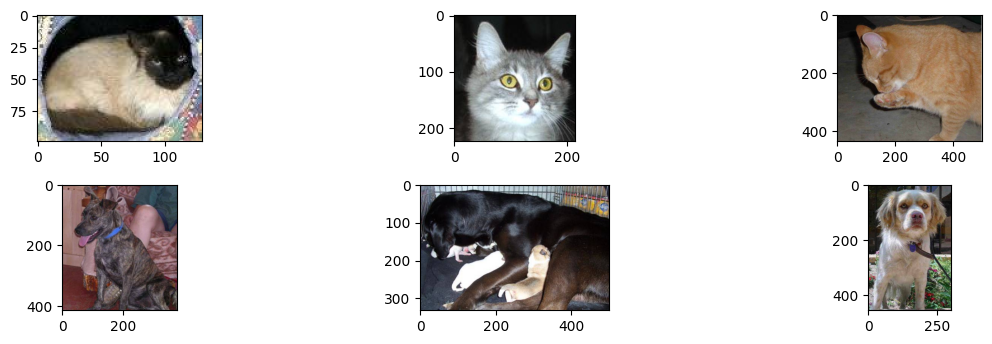

In [7]:
# plot a random image from training dataset
def get_random_class_based_image(label=0, num_img=2): # get a random image of cat or dog
    random_images = []
    while len(random_images)<num_img:
      random_num = np.random.randint(0, len(train_dataset))
      class_label = train_dataset.samples[random_num]
      if(class_label[1] == label):
        random_images.append(class_label[0])
    return random_images
random_images = []
num_img = 3
for i in range(2):
  random_images.append(get_random_class_based_image(i, num_img))
random_images = np.array(random_images).flatten()
# plot the images
plt.figure(figsize=(12, 5))
for i in range(num_img*2):
  plt.subplot(3, 3, i+1)
  data = plt.imread(random_images[i])
  plt.imshow(data)
plt.tight_layout()


In [145]:
train_dataset.classes

['cats', 'dogs']

In [148]:
train_dataset.find_classes(f'{path}/train')

(['cats', 'dogs'], {'cats': 0, 'dogs': 1})

In [6]:
# Take only 500 sample for development & testing
train_indices = np.random.choice(len(train_dataset), size=500, replace=False)
train_small_dataset = torch.utils.data.Subset(train_dataset, train_indices)
#test
test_indices = np.random.choice(len(testing_dataset), size=500, replace=False)
test_small_dataset = torch.utils.data.Subset(testing_dataset, test_indices)

In [25]:
len(train_small_dataset), len(test_small_dataset)

(500, 500)

In [26]:
# Create dataloader
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True,
                                           num_workers=2,  drop_last=True, pin_memory=True)
test_loader = torch.utils.data.DataLoader(testing_dataset, batch_size=64, shuffle=True, num_workers=2,
                                          pin_memory=True)

In [27]:
len(train_loader), len(test_loader)

(263, 40)

In [15]:
for X, y in train_loader:
  print(f'X shape: {X.shape} \t y shape: {y.shape} \t X dim: {X.ndim}')
  break

X shape: torch.Size([64, 3, 124, 124]) 	 y shape: torch.Size([64]) 	 X dim: 4


In [28]:
# Building the network
class CNN_network(nn.Module):
  def __init__(self,):
    super(CNN_network, self).__init__()
    self.sequencial = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(num_features=32), # Makes training more stable and faster
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

         nn.Conv2d(in_channels=32, out_channels=192, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(num_features=192), # Makes training more stable and faster
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Conv2d(in_channels=192, out_channels=128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(num_features=128), # Makes training more stable and faster
        nn.ReLU(),

        nn.AdaptiveAvgPool2d((1,1))  # shrink to 1x1 feature map
        )


    self.flat = nn.Flatten()

    self.linear1 = nn.Linear(in_features=128, out_features=32)
    self.relulin1 = nn.ReLU()

    # add dropout to randomely turn of som neurons
    self.dropout = nn.Dropout(p=0.3)

    self.output = nn.Linear(in_features=32, out_features=1)

  def forward(self, x):
    x = self.sequencial(x)
    x = self.flat(x)
    # print(f"X shape: {x.shape}")
    x = self.linear1(x)
    x = self.relulin1(x)
    x = self.dropout(x)
    x = self.output(x)
    return x

model = CNN_network().to(device)
model

CNN_network(
  (sequencial): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(192, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (flat): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=128, out_features=32, bias=True)
  (relulin1): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (output): Linear(in_

In [11]:
# test the model
dumy_dataset = torch.randn(1, 3, 124, 124).to(device)
# test the model
pred = model(dumy_dataset)

X shape: torch.Size([1, 128])


In [29]:
# optimize the model parameters
loss_fun = nn.BCEWithLogitsLoss()
optimizer_fun = torch.optim.Adam(params=model.parameters(), lr=0.0005,
                                 weight_decay=1e-4 #  helps prevent overfitting
                                 )

In [30]:
# train the model
def train_model(model, dataloader, loss_fun, optimizer_fun, threshold=0.5):
  model.train()
  total_loss, total_acc = 0, 0
  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    y = y.unsqueeze(1).float()

    optimizer_fun.zero_grad() # reset the gradient

    y_pred = model(X) # predict the inputs

    pred_probs = torch.sigmoid(y_pred) # the the probability of predicted labels
    pred_label = (pred_probs>threshold).int() # get actual label based on the threshold

    # print(f'pred_probs: {pred_probs} \n pred_label: {pred_label}')
    loss = loss_fun(y_pred, y) # calculate the loss
    total_loss += loss.detach().item()

    # Backpropagation
    loss.backward() # compute the gradient
    optimizer_fun.step() # update the weidth

    # training accuracy score
    total_acc += (pred_label == y.int()).float().sum().item()

    if batch % 100 ==0:
      print(f'loss: {loss.item()}\t [{(batch+1)*len(X)}/{len(dataloader.dataset)}]')
  return total_loss/len(dataloader), total_acc/len(dataloader.dataset)

In [31]:
# validate the training model

def validate_model(model, dataloader, loss_fun, threshold=0.5):
  model.eval()
  total_loss, total_acc = 0,0
  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      y = y.unsqueeze(1).float()
      y_pred = model(X)

      pred_probs = torch.sigmoid(y_pred)
      pred_label = (pred_probs > threshold).int()

      total_loss += loss_fun(y_pred, y).detach().item()
      total_acc += (pred_label == y.int()).float().sum().item()
  return total_loss/len(dataloader), total_acc/len(dataloader.dataset)

In [ ]:
epochs= 20
training_history = {'tr-loss': [], 'tr-acc': []}
val_history = {'val-loss': [], 'val-acc': []}
for i in range(epochs):
  print(f'Epochs {i+1} ----------------')
  tr_loss, tr_acc = train_model(model, train_loader, loss_fun, optimizer_fun, 0.5)
  training_history['tr-loss'].append(tr_loss)
  training_history['tr-acc'].append(tr_acc)

  val_loss, val_acc = validate_model(model, test_loader, loss_fun, 0.5)
  print(f'val loss: {val_loss} \t val accuracy: {val_acc}')
  val_history['val-loss'].append(val_loss)
  val_history['val-acc'].append(val_acc)